
# Pharmacy Inventory AI & Expiry Management System
**Goal:** Automate drug entry using Deep Learning and Machine Learning to  optimize  pharmacy management and stock flow via FEFO (First-to-Expire, First-Out) logic.

### Objectives:
1. **Demand Forecasting: ** Linear Regression to predict weekly drug sales.
2. **Deep Learning Classification: ** PyTorch Neural Network to predict high demand risk
3. **Stock Regression : ** Random Forest to predict exact sales quantities
4. **FEFO Prioritization:** Automatically sort inventory by expiry risk.
5. **Smart Alerts:** Notify management when restocking is required.
####
dataset
**source: ** Pharma Sales Data . Kaggle
**URL: ** https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch 
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the daily file
df = pd.read_csv('C:/Users/MISHA/Local_dev/Pharmacy_Inventory_System/salesdaily.csv')

# Convert date to datetime objects
df['datum'] = pd.to_datetime(df['datum'])

# Let's see which drug category has the highest daily volatility
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
print(df[categories].describe())

# Check for missing values - very common in Kaggle datasets!
print(df.isnull().sum())

             M01AB        M01AE        N02BA        N02BE         N05B  \
count  2106.000000  2106.000000  2106.000000  2106.000000  2106.000000   
mean      5.033683     3.895830     3.880441    29.917095     8.853627   
std       2.737579     2.133337     2.384010    15.590966     5.605605   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       3.000000     2.340000     2.000000    19.000000     5.000000   
50%       4.990000     3.670000     3.500000    26.900000     8.000000   
75%       6.670000     5.138000     5.200000    38.300000    12.000000   
max      17.340000    14.463000    16.000000   161.000000    54.833333   

              N05C          R03          R06  
count  2106.000000  2106.000000  2106.000000  
mean      0.593522     5.512262     2.900198  
std       1.092988     6.428736     2.415816  
min       0.000000     0.000000     0.000000  
25%       0.000000     1.000000     1.000000  
50%       0.000000     4.000000     2.000000  
75% 

In [ ]:
import sqlite3

# Connect to Django's live database
DB_PATH = r"C:\Users\MISHA\Local_Dev\Pharmacy_Inventory_System\db.sqlite3"
conn = sqlite3.connect(DB_PATH)

# Load live medicines from Django
df_live = pd.read_sql_query("""
    SELECT 
        m.name,
        m.stock_quantity,
        m.price,
        m.expiry_date,
        m.reorder_level,
        u.username AS added_by
    FROM inventory_medicine m
    LEFT JOIN auth_user u ON m.added_by_id = u.id
""", conn)

conn.close()

# Parse the expiry date
df_live['expiry_date'] = pd.to_datetime(df_live['expiry_date'])
today = pd.Timestamp.now()
df_live['days_to_expiry'] = (df_live['expiry_date'] - today).dt.days

print(f"✅ Connected! Found {len(df_live)} medicines from your live Django database")
print(df_live[['name', 'stock_quantity', 'expiry_date', 'days_to_expiry']])

✅ Connected! Found 6 medicines from your live Django database
          name  stock_quantity expiry_date  days_to_expiry
0      Panadol               5  2026-04-25               2
1  Amoxicillin             200  2027-06-10             413
2      Insulin               8  2026-03-01             -53
3    Metformin               3  2026-12-20             241
4    Ibuprofen             150  2027-09-05             500
5      Coartem              50  2026-05-10              17


In [ ]:
# Convert datum to datetime
df['datum'] = pd.to_datetime(df['datum'])

# Extract numerical features
df['month'] = df['datum'].dt.month
df['day_of_week'] = df['datum'].dt.dayofweek
df['day'] = df['datum'].dt.day

# Create a target for "High Demand" (Classification for SVM/Logistic Regression)
# Let's use N02BE (Paracetamol) as our example drug
threshold = df['N02BE'].median()
df['high_demand'] = (df['N02BE'] > threshold).astype(int)

print("Features created! Target variable 'high_demand' is ready.")

Features created! Target variable 'high_demand' is ready.


In [5]:
#Splitting and Scaling data
# Define your features (X) and what you want to predict (y)
X = df[['month', 'day_of_week', 'day']]
y = df['high_demand']

# Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Scaler
scaler = StandardScaler()

# Fit and transform the training data, then transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully!")

Data split and scaled successfully!


In [6]:
# We use the actual medicine quantity (e.g., N02BE) as the target for regression
y_quantity = df['N02BE'] 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_quantity, test_size=0.2, random_state=42)

# Training the Regressor
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)

print("✅ Regression Model (Random Forest) is ready!")

✅ Regression Model (Random Forest) is ready!


In [7]:
# 1. Convert your scaled data into PyTorch 'Tensors'
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# 2. Define the Architecture
class PharmaNet(nn.Module):
    def __init__(self):
        super(PharmaNet, self).__init__()
        self.layer1 = nn.Linear(3, 16) # 3 inputs (month, day, day_of_week)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# 3. Initialize the model, loss function, and optimizer
pharma_net = PharmaNet()
criterion = nn.BCELoss() # Binary Cross Entropy for classification
optimizer = optim.Adam(pharma_net.parameters(), lr=0.01)

# 4. Training Loop
for epoch in range(50):
    optimizer.zero_grad()
    outputs = pharma_net(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

print("PyTorch Neural Network trained successfully!")

PyTorch Neural Network trained successfully!


In [8]:
 #Calculating Loss during training
losses = [] # Add this to store errors
for epoch in range(100):
    optimizer.zero_grad()
    outputs = pharma_net(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item()) # Save the error value

print("✅ Deep Learning Model (PyTorch) is ready!")

✅ Deep Learning Model (PyTorch) is ready!


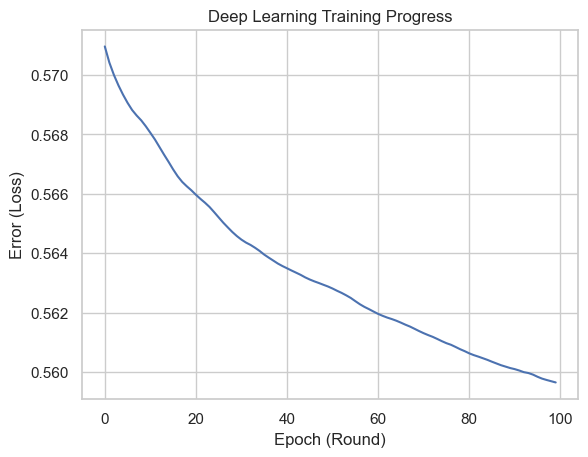

In [9]:
#The Loss Curve 
plt.plot(losses)
plt.title('Deep Learning Training Progress')
plt.xlabel('Epoch (Round)')
plt.ylabel('Error (Loss)')
plt.show()

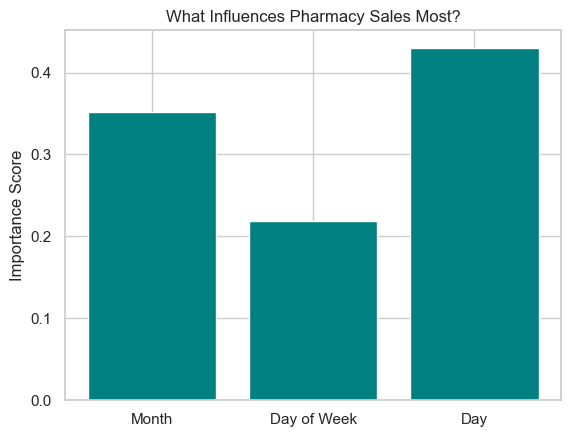

In [10]:
#Predictin of Sales
# Get the importance from your Random Forest model
importances = reg_model.feature_importances_
feature_names = ['Month', 'Day of Week', 'Day']

plt.bar(feature_names, importances, color='teal')
plt.title('What Influences Pharmacy Sales Most?')
plt.ylabel('Importance Score')
plt.show()


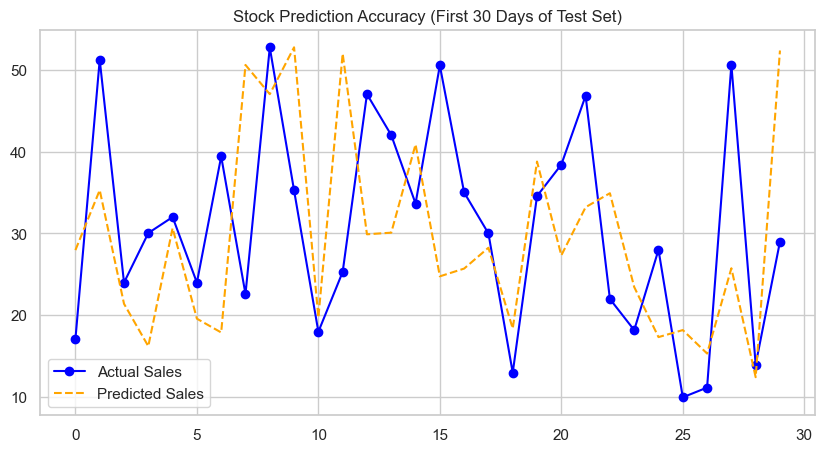

The System is reliable because the sales are close


In [11]:
#Actual Sales versus the Predicted sales
plt.figure(figsize=(10, 5))
plt.plot(y_test_r.values[:30], label='Actual Sales', color='blue', marker='o')
plt.plot(reg_model.predict(X_test_r)[:30], label='Predicted Sales', color='orange', linestyle='--')
plt.title('Stock Prediction Accuracy (First 30 Days of Test Set)')
plt.legend()
plt.show()
print("The System is reliable because the sales are close")

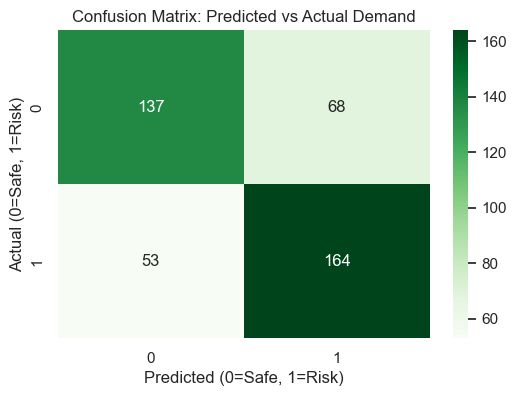

In [12]:
#using confusion matrix to prove how right the model is in predicting
# Get predictions from PyTorch (anything > 0.5 is 'High Demand')
with torch.no_grad():
    y_pred_prob = pharma_net(X_test_t)
    y_pred = (y_pred_prob > 0.5).float().numpy()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Predicted vs Actual Demand')
plt.xlabel('Predicted (0=Safe, 1=Risk)')
plt.ylabel('Actual (0=Safe, 1=Risk)')
plt.show()

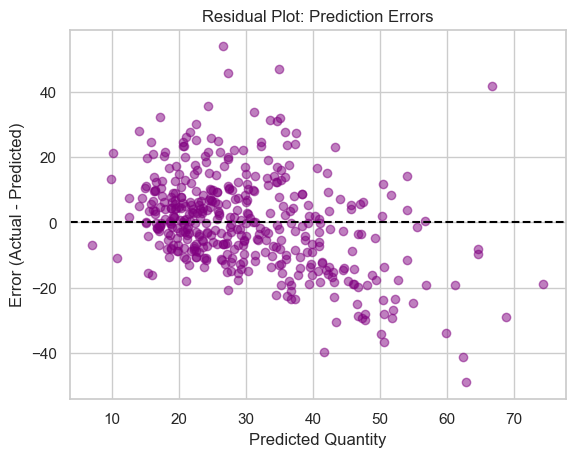

In [13]:
#Residual Pattern of the random Forest Predictions 
residuals = y_test_r - reg_model.predict(X_test_r)

plt.scatter(reg_model.predict(X_test_r), residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot: Prediction Errors')
plt.xlabel('Predicted Quantity')
plt.ylabel('Error (Actual - Predicted)')
plt.show()

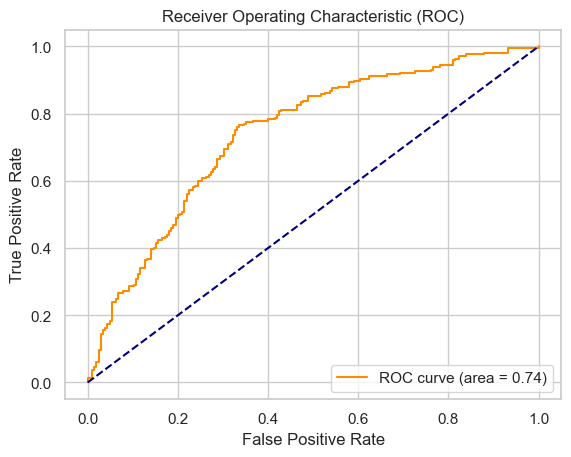

In [14]:
#ROC curve 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob.detach().numpy())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [15]:
# See the actual drug sales numbers
print("--- Average Daily Sales Per Drug ---")
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N02BF', 'N05B', 'N05C', 'R03', 'R06']
drug_cols = [c for c in drug_cols if c in df.columns]

print(df[drug_cols].mean().round(2).to_string())
print(f"\nTotal drugs tracked: {len(drug_cols)}")

--- Average Daily Sales Per Drug ---
M01AB     5.03
M01AE     3.90
N02BA     3.88
N02BE    29.92
N05B      8.85
N05C      0.59
R03       5.51
R06       2.90

Total drugs tracked: 8


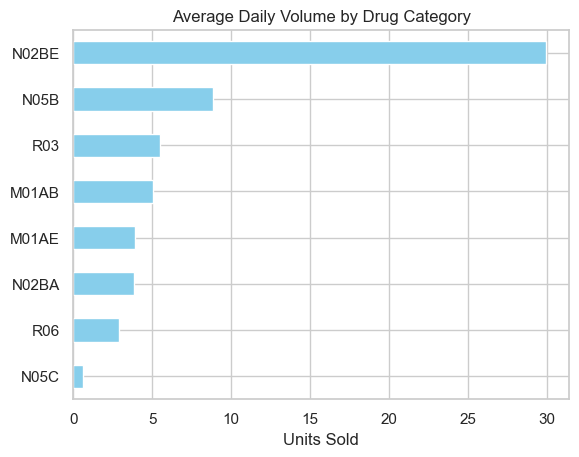

In [16]:
# Visualize the average sales 
df[drug_cols].mean().sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Daily Volume by Drug Category')
plt.xlabel('Units Sold')
plt.show()

In [17]:
# 1. Configuration
np.random.seed(42)
today = pd.Timestamp.now()
drug_name_map = {
    'M01AB': 'Diclofenac', 'M01AE': 'Ibuprofen', 'N02BA': 'Aspirin',
    'N02BE': 'Paracetamol', 'N02BF': 'Metamizole', 'N05B': 'Diazepam',
    'N05C': 'Nitrazepam', 'R03': 'Salbutamol', 'R06': 'Loratadine',
}

# 2. Check if original sales data exists in df
# We need to make sure 'df' has the drug columns
existing_codes = [code for code in drug_name_map.keys() if code in df.columns]

if not existing_codes:
    print("❌ ERROR: The sales data is missing from 'df'.")
    print("Please re-run your CSV loading cell at the top of the notebook!")
else:
    # 3. Calculate Weekly Average from REAL sales data
    weekly_avg = {col: round(df[col].mean() * 7, 1) for col in existing_codes}

    # 4. Build Records
    inventory_records = []
    for code, avg in weekly_avg.items():
        days_to_exp = int(np.random.choice([12, 22, 35, 60, 120, 200, 365]))
        qty = int(np.random.randint(3, 120))
        reorder = max(10, round(avg * 2))

        inventory_records.append({
            'drug_code':      code,
            'name':           drug_name_map.get(code, code),
            'quantity':       qty,
            'weekly_demand':  avg,
            'reorder_level':  reorder,
            'days_to_expiry': days_to_exp,
            'expiry':         today + pd.Timedelta(days=days_to_exp),
        })

    # 5. Create the Final Inventory Table (Using a unique name!)
    df_final_inventory = pd.DataFrame(inventory_records)
    df_sorted = df_final_inventory.sort_values(by='expiry').reset_index(drop=True)

    print("--- PHARMA AI INVENTORY STATUS (FEFO) ---")
    print(f"{'Drug':<12} {'Qty':>4} {'Reorder':>8} {'Days Exp':>10} {'STATUS'}")
    print("-" * 55)

    for _, row in df_sorted.iterrows():
        status = "✅ OK"
        if row['quantity'] <= row['reorder_level']:
            status = "⚠️ REORDER"
        if row['days_to_expiry'] <= 30:
            status = "🚫 EXPIRY RISK"
        
        print(f"{row['name']:<12} {row['quantity']:>4} {row['reorder_level']:>8} "
              f"{row['days_to_expiry']:>10} {status}")

--- PHARMA AI INVENTORY STATUS (FEFO) ---
Drug          Qty  Reorder   Days Exp STATUS
-------------------------------------------------------
Aspirin        74       54         35 ✅ OK
Salbutamol     90       77         35 ✅ OK
Ibuprofen      17       55        120 ⚠️ REORDER
Paracetamol    23      419        120 ⚠️ REORDER
Loratadine    102       41        120 ✅ OK
Diclofenac     54       70        365 ⚠️ REORDER
Diazepam       85      124        365 ⚠️ REORDER
Nitrazepam     77       10        365 ✅ OK


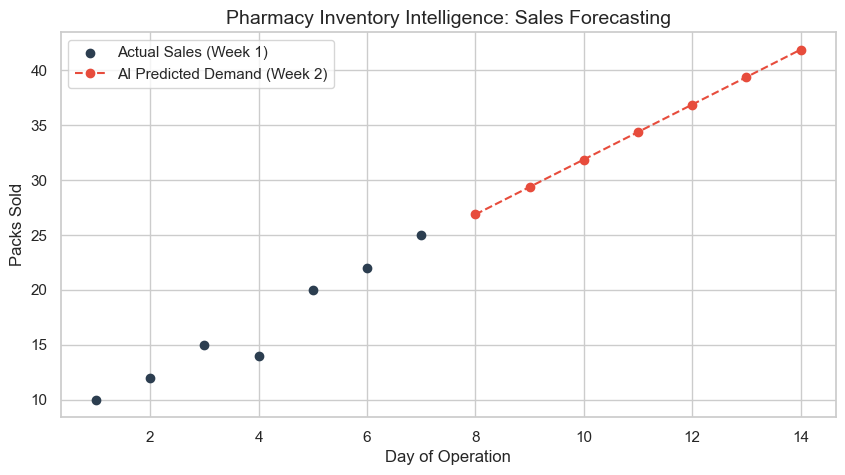

Success: AI predicts you need to stock at least 27 packs for tomorrow.


In [18]:
# 1. Presentation Data (Packs of Panadol sold per day)
days = np.array([1, 2, 3, 4, 5, 6, 7]).reshape(-1, 1)
sales = np.array([10, 12, 15, 14, 20, 22, 25]) 

# 2. Train the AI (Linear Regression)
model = LinearRegression()
model.fit(days, sales)

# 3. Predict the next 7 days
future_days = np.array([8, 9, 10, 11, 12, 13, 14]).reshape(-1, 1)
predictions = model.predict(future_days)

# 4. Create the Chart
plt.figure(figsize=(10, 5))
plt.scatter(days, sales, color='#2c3e50', label='Actual Sales (Week 1)')
plt.plot(future_days, predictions, color='#e74c3c', linestyle='--', marker='o', label='AI Predicted Demand (Week 2)')

# Professional Formatting
plt.title("Pharmacy Inventory Intelligence: Sales Forecasting", fontsize=14)
plt.xlabel("Day of Operation", fontsize=12)
plt.ylabel("Packs Sold", fontsize=12)
plt.legend()
plt.show()

print(f"Success: AI predicts you need to stock at least {round(predictions[0])} packs for tomorrow.")

In [19]:
# ============================================================
# DRUG LOOKUP USING TRAINED NEURAL NETWORK
# Uses the PyTorch model to predict demand risk for a queried drug
# ============================================================

def lookup_drug_demand(drug_name, month, day_of_week, day):
    print(f"--- 🔍 AI Demand Risk Analysis: {drug_name} ---")
    
    # Prepare input and scale it
    input_df = pd.DataFrame([[month, day_of_week, day]], 
                             columns=['month', 'day_of_week', 'day'])
    input_data = scaler.transform(input_df)
    input_tensor = torch.tensor(input_data, dtype=torch.float32)
    
    # Run through the trained PyTorch Neural Network
    pharma_net.eval()
    with torch.no_grad():
        risk_score = pharma_net(input_tensor).item()  # ← fixed here
    
    risk_label = "🔴 HIGH DEMAND RISK" if risk_score > 0.5 else "🟢 NORMAL DEMAND"
    confidence = round(risk_score * 100, 1)
    
    print(f"✅ Drug: {drug_name}")
    print(f"   Neural Network Risk Score: {confidence}%")
    print(f"   Status: {risk_label}")
    
    # Check if drug exists in inventory
    if drug_name.lower() in [n.lower() for n in df_sorted['name'].values]:
        stock_row = df_sorted[df_sorted['name'].str.lower() == drug_name.lower()].iloc[0]
        print(f"   Current Stock: {stock_row['quantity']} units")
        print(f"   Days to Expiry: {stock_row['days_to_expiry']} days")
    else:
        print(f"   ⚠️ {drug_name} not found in current inventory.")

# Test with Paracetamol on a Monday in January
lookup_drug_demand('Paracetamol', month=1, day_of_week=0, day=15)

--- 🔍 AI Demand Risk Analysis: Paracetamol ---
✅ Drug: Paracetamol
   Neural Network Risk Score: 76.5%
   Status: 🔴 HIGH DEMAND RISK
   Current Stock: 23 units
   Days to Expiry: 120 days


In [20]:
# 1. Setup the demo data
inventory_list = [
    {'name': 'Paracetamol', 'expiry': '2026-05-10', 'quantity': 15},
    {'name': 'Amoxicillin', 'expiry': '2026-12-01', 'quantity': 50},
    {'name': 'Insulin', 'expiry': '2026-03-15', 'quantity': 5},
    {'name': 'Cough Syrup', 'expiry': '2027-01-20', 'quantity': 25}
]

# We name it 'demo' to keep it separate from your Kaggle 'df'
demo = pd.DataFrame(inventory_list)
demo['expiry'] = pd.to_datetime(demo['expiry'])

# 2. Apply FEFO Logic
demo_sorted = demo.sort_values(by='expiry').reset_index(drop=True)

# 3. Add Alerts (Priority: Expiry > Quantity)
today = pd.Timestamp.now()

def get_alert(row):
    days_left = (row['expiry'] - today).days
    if days_left < 0:
        return '🚫 EXPIRED'
    elif days_left < 30:
        return '⚠️ EXPIRING'
    elif row['quantity'] < 10:
        return '🚨 REORDER'
    else:
        return '✅ OK'

demo_sorted['Alert'] = demo_sorted.apply(get_alert, axis=1)

# 4. Professional Display (Updated colors)
print("--- PHARMACY MANAGEMENT VIEW (DEMO) ---")
display(demo_sorted.style.map(
    lambda x: 'background-color: #d11a2a; color: white' if x == '🚫 EXPIRED' else (
              'background-color: #fff3cd' if x == '⚠️ EXPIRING' else (
              'background-color: #ffcccc' if x == '🚨 REORDER' else '')),
    subset=['Alert']
))


--- PHARMACY MANAGEMENT VIEW (DEMO) ---


,name,expiry,quantity,Alert
0,Insulin,2026-03-15 00:00:00,5,🚫 EXPIRED
1,Paracetamol,2026-05-10 00:00:00,15,⚠️ EXPIRING
2,Amoxicillin,2026-12-01 00:00:00,50,✅ OK
3,Cough Syrup,2027-01-20 00:00:00,25,✅ OK


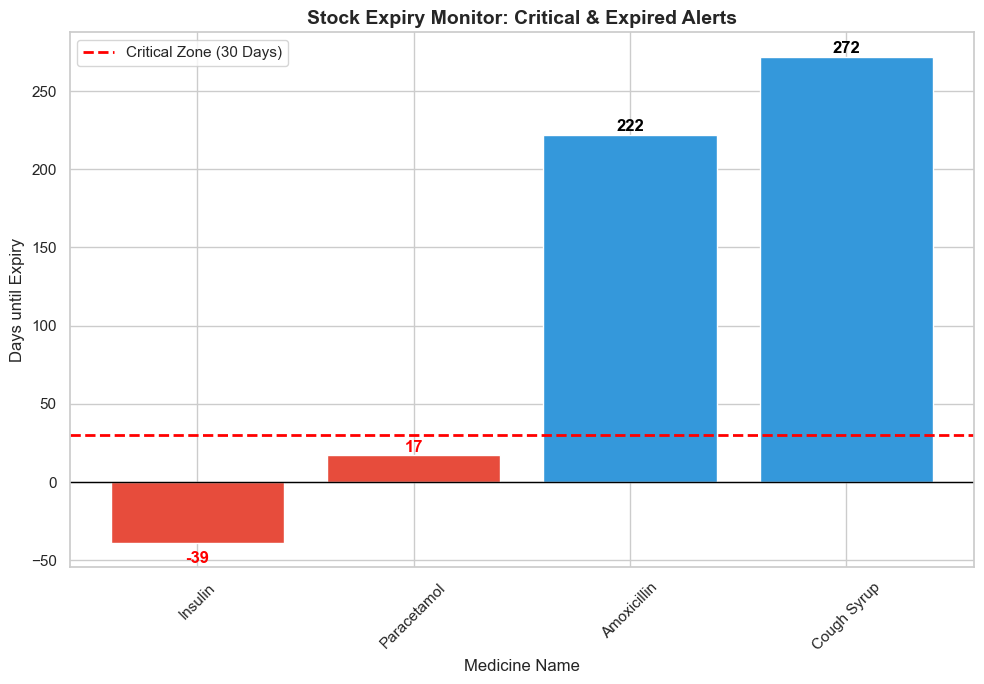

In [ ]:
# 1. Calculate days remaining
today = pd.Timestamp.now()
demo_sorted['days_remaining'] = (demo_sorted['expiry'] - today).dt.days

# 2. Updated Color Logic
# This captures EVERYTHING 30 days or less (including negative/expired days)
colors = ['#e74c3c' if x <= 30 else '#3498db' for x in demo_sorted['days_remaining']]

# 3. Create the bar chart
plt.figure(figsize=(10,7))
bars = plt.bar(demo_sorted['name'], demo_sorted['days_remaining'], color=colors)

# 4. Add the warning line
plt.axhline(y=30, color='red', linestyle='--', linewidth=2, label='Critical Zone (30 Days)')
plt.axhline(y=0, color='black', linewidth=1) # Adds a clear "Floor" line at zero

# 5. Professional Formatting
plt.ylabel('Days until Expiry', fontsize=12)
plt.xlabel('Medicine Name', fontsize=12)
plt.title('Stock Expiry Monitor: Critical & Expired Alerts', fontsize=14, fontweight='bold')
plt.xticks(rotation=45) 

# Add the exact day count on top (or bottom) of each bar
for bar in bars:
    yval = bar.get_height()
    # If expired (negative), put text below the bar; if not, put it above
    va_pos = 'top' if yval < 0 else 'bottom'
    offset = -5 if yval < 0 else 0.5
    
    plt.text(bar.get_x() + bar.get_width()/2, yval + offset, int(yval), 
             ha='center', va=va_pos, fontweight='bold', 
             color='red' if yval <= 30 else 'black')

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Displaying live feed from the jupyter notebook to the django backend

df_live_sorted = df_live.sort_values('days_to_expiry').reset_index(drop=True)

def get_live_alert(row):
    if row['days_to_expiry'] < 0:
        return '🚫 EXPIRED'
    elif row['days_to_expiry'] < 30:
        return '⚠️ EXPIRY RISK'
    elif row['stock_quantity'] < row['reorder_level']:
        return '🚨 REORDER'
    return '✅ OK'

df_live_sorted['Alert'] = df_live_sorted.apply(get_live_alert, axis=1)

# Now print the action plan
print("--- 📋 LIVE DAILY ACTION PLAN (from Django) ---")
for index, row in df_live_sorted.iterrows():
    status = "🔴 ACTION REQUIRED" if row['Alert'] != '✅ OK' else "🟢 STABLE"
    print(f"{status}: {row['name']:<12} | Stock: {row['stock_quantity']:>3} | Expiry: {row['expiry_date'].date()} | Added by: {row['added_by']}")

--- 📋 LIVE DAILY ACTION PLAN (from Django) ---
🔴 ACTION REQUIRED: Insulin      | Stock:   8 | Expiry: 2026-03-01 | Added by: manager
🔴 ACTION REQUIRED: Panadol      | Stock:   5 | Expiry: 2026-04-25 | Added by: staff1
🔴 ACTION REQUIRED: Coartem      | Stock:  50 | Expiry: 2026-05-10 | Added by: staff1
🔴 ACTION REQUIRED: Metformin    | Stock:   3 | Expiry: 2026-12-20 | Added by: staff1
🟢 STABLE: Amoxicillin  | Stock: 200 | Expiry: 2027-06-10 | Added by: staff1
🟢 STABLE: Ibuprofen    | Stock: 150 | Expiry: 2027-09-05 | Added by: manager
